1. Vad har ANN modellerna inspirerats av?
Svar: ANN modellerna har inspirerats av den mänskliga hjärnans neuronnätverk. 

2. Vad refererar “djup” till i begreppet “djupinlärning”?
Svar: Det man refererar till är att man har flera lager av noder i ett neuralt nätverk. De så kallade "hidden layers". Vi kan ha många dolda lager men själva begreppet "djupinlärning" specificerar inte antal dolda lager för att vara djupt. Ofta använder man neurala nätverk synonymt med djupinlärning. 

3. Förklara vad som händer i figur 7.2, 7.3, figur 7.4 och figur 7.5. Varför används aktiveringsfunktioner?
Svar: I figur 7.2 visas 2 input-noder som 1 och x1. Dessa båda noder är kopplade till en output-nod med vikterna w1 och w2. Input-noderna multipliceras med vikterna och adderas. Kikar vi närmare så kan man se att detta är en enkel linjär regression. 

I figur 7.3 ser vi en mer komplex arkitektur för ett neuralt nätverk med input layer, hidden layer och output layer. Beräkningen eller rättare sagt algoritmen är fortfarande enkel linjär regression. 

Figur 7.4 visar exempel på två aktiveringsfunktioner

Figur 7.5 visar arkitektur för en single-layer-perceptron. Det som karraktäriserar perceptron-arkitekturen är att de är av typen feedforward, är fully connected/dense och har icke-linjära aktiveringsfunktioner. 

På frågan varför en aktiveringsfunktion används är helt enkelt för att vi ska få ett annat resultat än vad en enkel linjär regressionsmodell ger. Två exempel på aktiveringsfunktioner är Logistic/Sigmoid samt Rectified Linear Unit.

4. Har neurala nätverk få eller många parametrar?
Svar: Neurala nätverk har långt många fler parametrar än t ex en linjär regressionsmodell. 

5. Förklara intuitivt hur dropout-regularisering fungerar.
Svar: 

In [12]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor

# Generate synthetic regression data
X, y = make_regression(n_samples=1000, n_features=20, random_state=1)

print(X.shape, y.shape)
#print(X[:5])
print(y[:2], type(y))




(1000, 20) (1000,)
[43.37363827 98.0921698 ] <class 'numpy.ndarray'>


In [13]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=20)
# Create and fit the MLPRegressor model with early stopping
mlp = MLPRegressor(random_state=5,hidden_layer_sizes=(200, 100, 10), activation='relu')
mlp.fit(X_train, y_train)
# Evaluate the model on the test set
predictions = mlp.predict(X_test[:2])
print(y_test[:2], predictions)



[214.58831339 367.6099045 ] [207.06313276 363.80322841]


c:\Projects\python_and_ai\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [14]:
#Calculating the number of weights for the model
total_weights = sum(w.size for w in mlp.coefs_)
total_biases = sum(b.size for b in mlp.intercepts_)
tota_params = total_weights + total_biases

print(f"Total weights: {total_weights}")
print(f"Total biases: {total_biases}")
print(f"Total parameters: {tota_params}")

Total weights: 25010
Total biases: 311
Total parameters: 25321


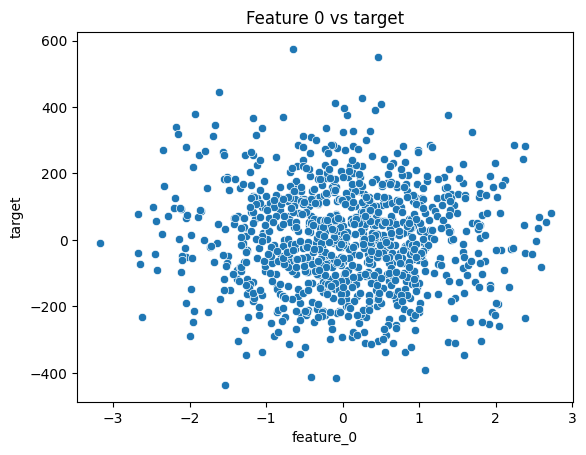

In [15]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

# 1. Skapa datasetet, redan gjort ovan
#X, y = make_regression(n_samples=1000, n_features=20, noise=10, random_state=1)

# 2. Konvertera X till DataFrame med kolumnnamn
df = pd.DataFrame(X, columns=[f"feature_{i}" for i in range(X.shape[1])])

# 3. Lägg till y som en target-kolumn
df["target"] = y

# 4. Plotta target mot en feature (ex feature_0)
sns.scatterplot(data=df, x="feature_0", y="target")
plt.title("Feature 0 vs target")
plt.show()


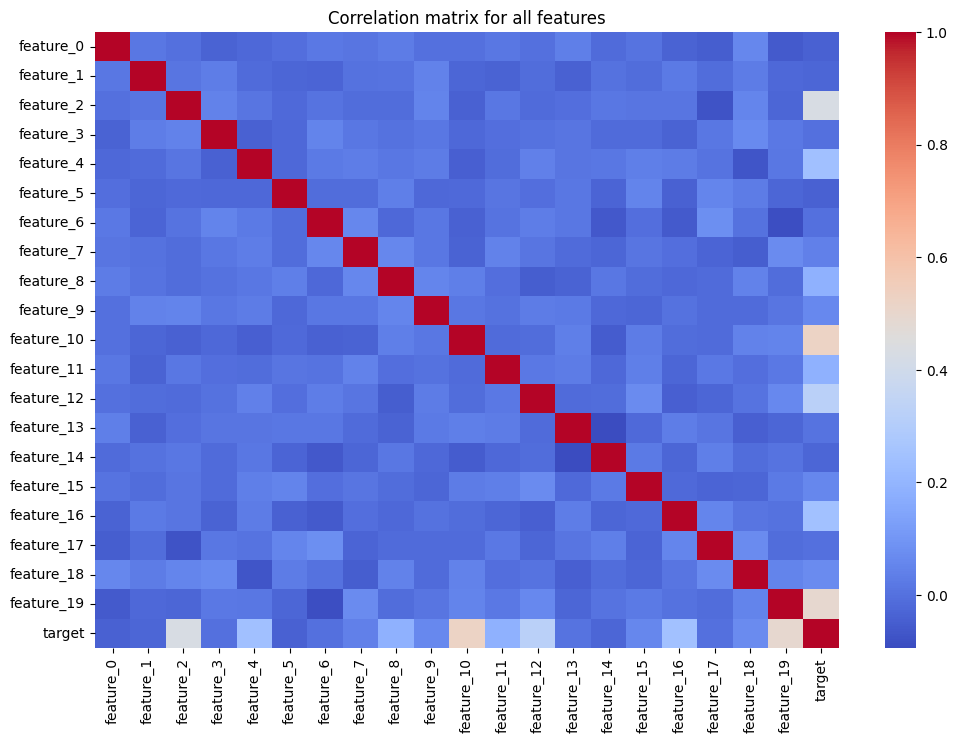

In [18]:
import numpy as np

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", annot=False)
plt.title("Correlation matrix for all features")
plt.show()

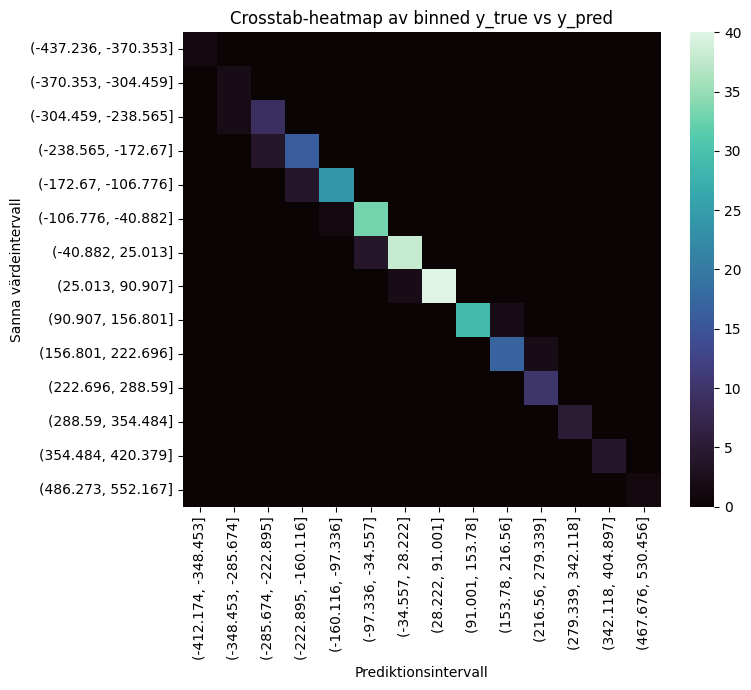

In [19]:
y_pred = mlp.predict(X_test)


# Välj antal bin (t.ex. 15) och skapa intervall
bins = 15
y_true_b = pd.cut(y_test, bins=bins)
y_pred_b = pd.cut(y_pred, bins=bins)

ct = pd.crosstab(y_true_b, y_pred_b)

plt.figure(figsize=(8, 7))
sns.heatmap(ct, cmap="mako", norm=None)  # eller norm=LogNorm() för stor dynamik
plt.title("Crosstab-heatmap av binned y_true vs y_pred")
plt.xlabel("Prediktionsintervall")
plt.ylabel("Sanna värdeintervall")
plt.tight_layout()
plt.show()


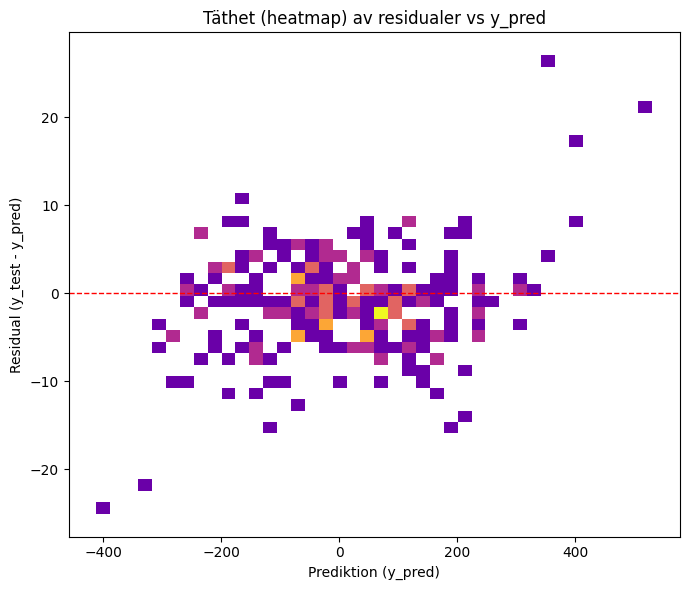

In [20]:
residuals = y_test - y_pred

plt.figure(figsize=(7, 6))
sns.histplot(
    x=y_pred, y=residuals,
    bins=40,
    pmax=0.999,
    cmap="plasma"
)
plt.axhline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Prediktion (y_pred)")
plt.ylabel("Residual (y_test - y_pred)")
plt.title("Täthet (heatmap) av residualer vs y_pred")
plt.tight_layout()
plt.show()